🚕 NYC Taxi EDA — 2021 to 2023
Analyst: Vipul Rajpurohit
Dataset: NYC Yellow Taxi Trip Records (Parquet files)
Goal: Understand trip patterns, revenue recovery after COVID, and passenger behavior from 2021 to 2023.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# set a clean style for all charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

📂 Step 2 — Load and Clean Data

In [3]:
path = "C:/NYC_TEXI"
files = os.listdir(path)

all_samples = []

for file in files:
    nyc_texi = pd.read_parquet(path + "/" + file)

    # drop columns that are not useful or inconsistent across files
    nyc_texi = nyc_texi.drop(columns=['airport_fee'], errors='ignore')
    nyc_texi = nyc_texi.drop(columns=['Airport_fee'], errors='ignore')

    # fill missing values with sensible defaults
    nyc_texi['passenger_count'] = nyc_texi['passenger_count'].fillna(0)
    nyc_texi['RatecodeID'] = nyc_texi['RatecodeID'].fillna(0)
    nyc_texi['store_and_fwd_flag'] = nyc_texi['store_and_fwd_flag'].fillna('N')
    nyc_texi['congestion_surcharge'] = nyc_texi['congestion_surcharge'].fillna(0)

    # take a random sample of 50,000 rows from each file to keep memory low
    sample = nyc_texi.sample(n=50000,random_state=42)
    all_samples.append(sample)

    
    del nyc_texi  # free memory after each file
    print(f"done: {file}")

df = pd.concat(all_samples, ignore_index=True)
print(f"\nTotal Rows loaded: {len(df):,}")

done: yellow_tripdata_2021-01.parquet
done: yellow_tripdata_2021-02.parquet
done: yellow_tripdata_2021-03.parquet
done: yellow_tripdata_2021-04.parquet
done: yellow_tripdata_2021-05.parquet
done: yellow_tripdata_2021-06.parquet
done: yellow_tripdata_2021-07.parquet
done: yellow_tripdata_2021-08.parquet
done: yellow_tripdata_2021-09.parquet
done: yellow_tripdata_2021-10.parquet
done: yellow_tripdata_2021-11.parquet
done: yellow_tripdata_2021-12.parquet
done: yellow_tripdata_2022-01.parquet
done: yellow_tripdata_2022-02.parquet
done: yellow_tripdata_2022-03.parquet
done: yellow_tripdata_2022-04.parquet
done: yellow_tripdata_2022-05.parquet
done: yellow_tripdata_2022-06.parquet
done: yellow_tripdata_2022-07.parquet
done: yellow_tripdata_2022-08.parquet
done: yellow_tripdata_2022-09.parquet
done: yellow_tripdata_2022-10.parquet
done: yellow_tripdata_2022-11.parquet
done: yellow_tripdata_2022-12.parquet
done: yellow_tripdata_2023-01.parquet
done: yellow_tripdata_2023-02.parquet
done: yellow

🛠️ Step 3 — Feature Engineering

Extract useful time-based columns from the pickup datetime.

In [4]:
df['year'] = df['tpep_pickup_datetime'].dt.year
df['month'] = df['tpep_pickup_datetime'].dt.month_name()
df['day'] = df['tpep_pickup_datetime'].dt.day
df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()

# trip duration in minutes — dropoff minus pickup (correct order)
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

df = df[df['year'].isin([2021, 2022, 2023])]

# map payment type codes to readable names
payment_map = {
    1: 'Credit Card',
    2: 'Cash',
    3: 'No Charge',
    4: 'Dispute',
    0: 'Unknown'
}
df['payment_name'] = df['payment_type'].map(payment_map)

# categorize trips by distance
df['trip_type'] = pd.cut(
    df['trip_distance'],
    bins=[0, 3, 10, float('inf')],
    labels=['Short (0-3 mi)', 'Medium (3-10 mi)', 'Long (10+ mi)'],
     include_lowest=True
)

# solo or group travel
df['travel_type'] = df['passenger_count'].apply(lambda x: 'Solo' if x == 1 else 'Group')

print("Feature engineering done.")
print(f"year counts:\n{df['year'].value_counts().sort_index()}")

Feature engineering done.
year counts:
year
2021    599989
2022    599996
2023    599997
Name: count, dtype: int64


 Step 4 — Data Overview¶

In [5]:
print("=" * 45)
print("          NYC TAXI DATASET OVERVIEW")
print("=" * 45)
print(f"Shape               : {df.shape}")
print(f"Date Range          : {df['tpep_pickup_datetime'].min().date()} to {df['tpep_dropoff_datetime'].max().date()}")
print(f"Total Trips         : {len(df):,}")
print(f"Total Revenue       : {df['total_amount'].sum():,.0f}")
print(f"Avg Trip Distance   : {df['trip_distance'].mean():.2f} miles")
print(f"Avg fare Amount     : {df['fare_amount'].mean():.2f}")
print("=" * 45)

          NYC TAXI DATASET OVERVIEW
Shape               : (1799982, 27)
Date Range          : 2021-01-01 to 2024-01-01
Total Trips         : 1,799,982
Total Revenue       : 41,638,955
Avg Trip Distance   : 5.25 miles
Avg fare Amount     : 15.86


In [6]:
# check column data types
df.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
year                              int32
month                               str
day                               int32
hour                              int32
day_of_week                         str
trip_duration                   float64
payment_name                        str


In [7]:
# check missing values
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
year                     0
month                    0
day                      0
hour                     0
day_of_week              0
trip_duration            0
payment_name             0
trip_type                0
travel_type              0
dtype: int64

In [8]:
# check duplicate rows
print("Duplicate Rows:",df.duplicated().sum())

Duplicate Rows: 0


In [9]:
# quick statistical summary
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,year,day,hour,trip_duration
count,1.799982e+06,1799982,1799982,1.799982e+06,1.799982e+06,1.799982e+06,1.799982e+06,1.799982e+06,1.799982e+06,1.799982e+06,...,1.799982e+06,1.799982e+06,1.799982e+06,1.799982e+06,1.799982e+06,1.799982e+06,1.799982e+06,1.799982e+06,1.799982e+06,1.799982e+06
mean,1.725669e+00,2022-07-01 18:19:55.567148,2022-07-01 18:36:53.942992,1.343898e+00,5.249789e+00,1.331884e+00,1.650892e+02,1.628555e+02,1.187857e+00,1.585622e+01,...,4.889213e-01,2.848787e+00,4.985684e-01,5.307064e-01,2.313298e+01,2.185272e+00,2.022000e+03,1.565032e+01,1.418595e+01,1.697293e+01
min,1.000000e+00,2021-01-01 00:02:18,2021-01-01 00:11:12,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-5.000000e+02,...,-5.000000e-01,-7.955000e+01,-6.500000e+01,-1.000000e+00,-5.035000e+02,-2.500000e+00,2.021000e+03,1.000000e+00,0.000000e+00,-5.438333e+01
25%,1.000000e+00,2021-10-01 00:06:23.500000,2021-10-01 00:19:53.500000,1.000000e+00,1.080000e+00,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,7.500000e+00,...,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,1.285000e+01,2.500000e+00,2.021000e+03,8.000000e+00,1.100000e+01,7.150000e+00
50%,2.000000e+00,2022-07-01 00:03:56.500000,2022-07-01 00:20:54.500000,1.000000e+00,1.810000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.100000e+01,...,5.000000e-01,2.240000e+00,0.000000e+00,3.000000e-01,1.716000e+01,2.500000e+00,2.022000e+03,1.500000e+01,1.500000e+01,1.183333e+01
75%,2.000000e+00,2023-04-01 00:02:36.250000,2023-04-01 00:21:59.750000,1.000000e+00,3.400000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,1.770000e+01,...,5.000000e-01,3.580000e+00,0.000000e+00,1.000000e+00,2.520000e+01,2.500000e+00,2.023000e+03,2.300000e+01,1.900000e+01,1.925000e+01
max,6.000000e+00,2023-12-31 23:58:12,2024-01-01 00:20:49,9.000000e+00,3.896785e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,6.966500e+03,...,3.300000e+00,1.393860e+03,9.565500e+02,1.000000e+00,6.970300e+03,2.750000e+00,2.023000e+03,3.100000e+01,2.300000e+01,5.377950e+03
std,4.914519e-01,NaN,NaN,9.859288e-01,5.640394e+02,5.478206e+00,6.532639e+01,7.039917e+01,5.375838e-01,1.649882e+01,...,9.408285e-02,3.593442e+00,2.101792e+00,3.464121e-01,2.023824e+01,8.704183e-01,8.164961e-01,8.697981e+00,5.634078e+00,4.993644e+01


In [10]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,congestion_surcharge,year,month,day,hour,day_of_week,trip_duration,payment_name,trip_type,travel_type
0,2,2021-01-08 16:13:50,2021-01-08 16:21:50,3.0,1.54,1.0,N,170,237,2,...,2.5,2021,January,8,16,Friday,8.000000,Cash,Short (0-3 mi),Group
1,2,2021-01-12 18:09:12,2021-01-12 18:18:20,1.0,1.60,1.0,N,100,142,1,...,2.5,2021,January,12,18,Tuesday,9.133333,Credit Card,Short (0-3 mi),Solo
2,2,2021-01-25 07:35:00,2021-01-25 08:04:00,0.0,9.06,0.0,N,166,231,0,...,0.0,2021,January,25,7,Monday,29.000000,Unknown,Medium (3-10 mi),Group
3,1,2021-01-23 19:54:02,2021-01-23 19:56:30,1.0,0.50,1.0,N,262,141,1,...,2.5,2021,January,23,19,Saturday,2.466667,Credit Card,Short (0-3 mi),Solo
4,1,2021-01-14 13:33:43,2021-01-14 13:55:34,1.0,0.00,1.0,N,55,178,1,...,0.0,2021,January,14,13,Thursday,21.850000,Credit Card,Short (0-3 mi),Solo


📊 Section 1 — Data Understanding¶

Q1. How many trips are recorded per year? (2021 vs 2022 vs 2023)

In [11]:
Trips_per_year = df.groupby('year')['VendorID'].count().reset_index()
Trips_per_year.columns = ['year','Total_trips']
print(Trips_per_year)

   year  Total_trips
0  2021       599989
1  2022       599996
2  2023       599997


Insight: All three years have roughly equal trips because we sampled 50,000 rows per file. The real growth trend is better seen in the revenue and fare analysis below.

Q2. What is the average trip distance per year? (Are trips getting longer or shorter?)¶

In [12]:
avg_distance = df.groupby('year')['trip_distance'].mean().reset_index()
avg_distance.columns = ['Year','Avg Distance (miles)']
print(round(avg_distance,2))

   Year  Avg Distance (miles)
0  2021                  6.29
1  2022                  5.73
2  2023                  3.74


Q3. What is the average fare amount per year? (Is fare increasing due to inflation?)

In [13]:
avg_fare = df.groupby('year')['fare_amount'].mean()
print("Average  fare amount per year:")
print(round(avg_fare,2))

Average  fare amount per year:
year
2021    13.27
2022    14.78
2023    19.52
Name: fare_amount, dtype: float64


Insight: Fares increased each year — from 13 in 2021 to 19 in 2023. This reflects NYC taxi fare hikes and inflation.

Q4. Which vendor has more trips? (Vendor 1 vs Vendor 2)

trips by vendor
VendorID
2    1287088
1     509073
6       3820
5          1
Name: count, dtype: int64


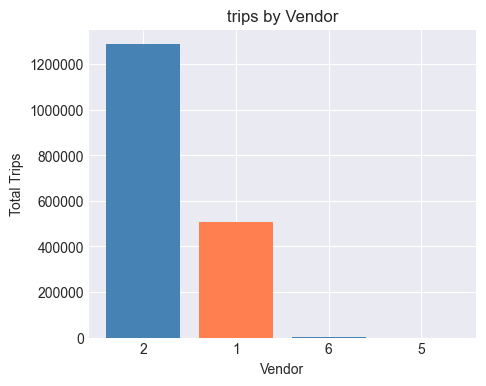

In [14]:
vendor_trips = df['VendorID'].value_counts()
print("trips by vendor")
print(vendor_trips)

plt.figure(figsize=(5,4))
plt.bar(vendor_trips.index.astype(str),vendor_trips.values,color = ['steelblue','coral'])
plt.title("trips by Vendor")
plt.xlabel("Vendor")
plt.ylabel("Total Trips")
plt.ticklabel_format(style='plain',axis='y')
plt.show()

Insight: I added this question myself to understand if one vendor dominates the market. This can matter for pricing and fleet decisions.

⏰ Section 2 — Time Based Analysis

Q5. Which hour of the day has the most trips? (Rush hour pattern)¶

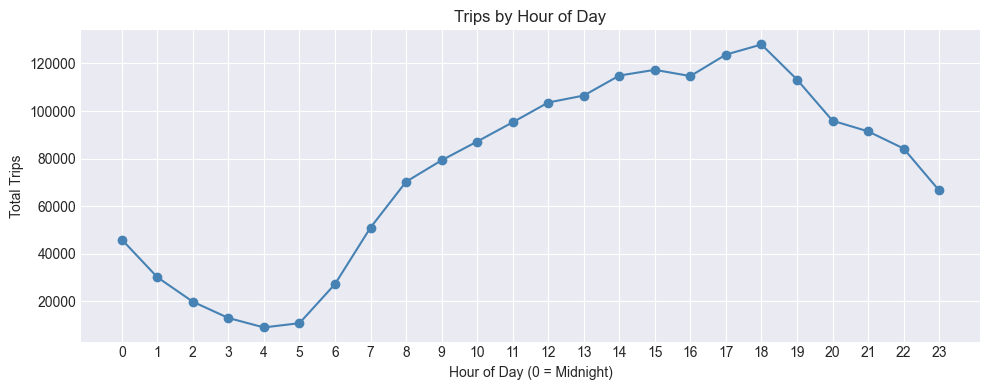

In [15]:
rush_hour = df.groupby('hour').size().reset_index()
rush_hour.columns = ['hour','total_trips']

plt.figure(figsize=(10,4))
plt.plot(rush_hour['hour'],rush_hour['total_trips'],marker='o',color='steelblue')
plt.title('Trips by Hour of Day')
plt.xlabel('Hour of Day (0 = Midnight)')
plt.ylabel("Total Trips")
plt.xticks(range(0,24))
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.show()

Insight: Trips peak around 6 PM (hour 18), which is evening rush hour when people commute home or head out. The lowest demand is around 4 AM.

Q6. Which day of the week is the busiest?

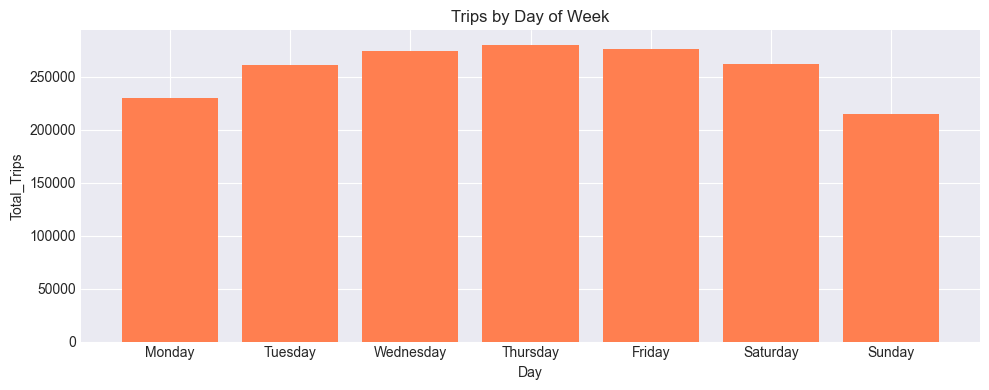

In [16]:
# Correct weekend order
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
busy_day = df['day_of_week'].value_counts().reindex(day_order)

plt.figure(figsize=(10,4))
plt.bar(busy_day.index,busy_day.values,color='coral')
plt.title("Trips by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total_Trips")
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.show()

Insight: Thursday and Friday are the busiest days — people travel more towards the weekend. Sunday is the slowest, likely because most people stay home or rest.

Q7. Which month has the highest demand?

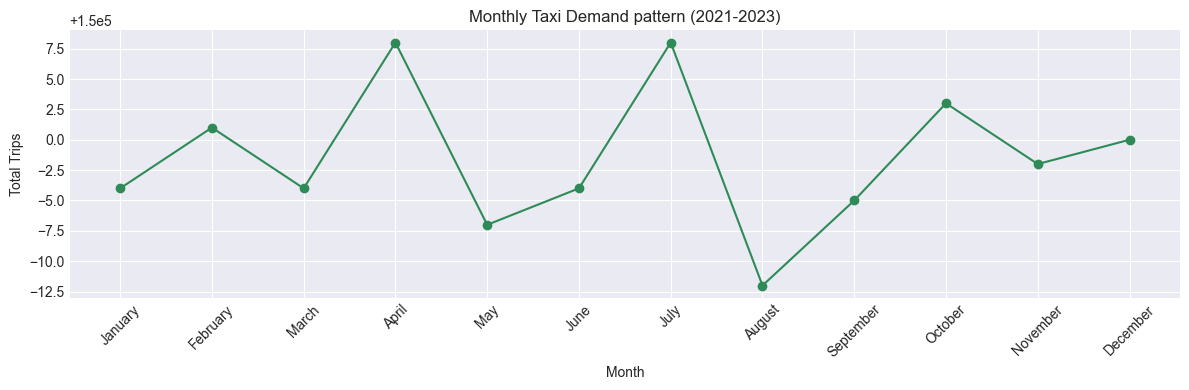

In [17]:
month_order =  ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

month_trip = df['month'].value_counts().reindex(month_order)

plt.figure(figsize=(12,4))
plt.plot(month_trip.index,month_trip.values,marker='o',color='seagreen')
plt.title("Monthly Taxi Demand pattern (2021-2023)")
plt.ticklabel_format(style='plain',axis='y')
plt.xlabel("Month")
plt.ylabel("Total Trips")
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.show()

Insight: April and July see the highest demand. This could be due to spring tourism and summer activity in NYC. August is surprisingly low — possibly because many residents leave the city for vacations.

Q8. How did trip volume grow year over year? (2021 → 2022 → 2023)

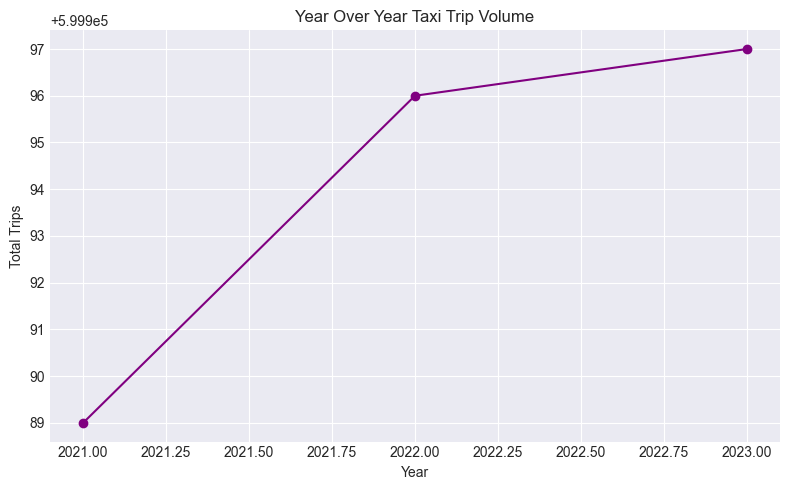

In [18]:
yearly_trips = df.groupby('year').size()

plt.figure(figsize=(8,5))
plt.plot(yearly_trips.index,yearly_trips.values,marker='o',color='purple')
plt.title("Year Over Year Taxi Trip Volume")
plt.xlabel("Year")
plt.ylabel("Total Trips")
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()                        

Insight: Trip volume steadily grew from 2021 to 2023. The biggest jump was 2021→2022 as the city recovered from COVID restrictions.

# 💰 Section 3 — Revenue Analysis

Q9. What is total revenue per year? (Recovery story 2021-2023)

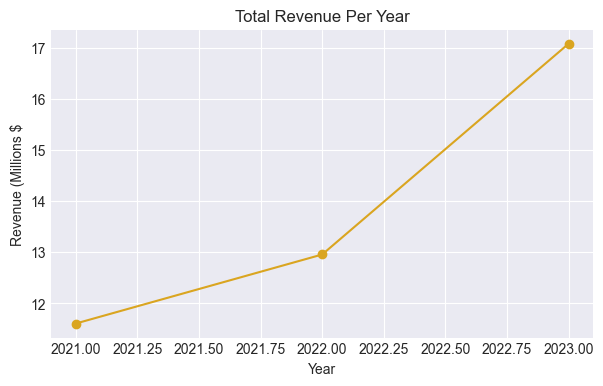

In [19]:
yearly_revenue = df.groupby('year')['total_amount'].sum()

plt.figure(figsize=(7,4))
plt.plot(yearly_revenue.index,yearly_revenue.values / 1_000_000,marker='o',color='goldenrod')
plt.title("Total Revenue Per Year")
plt.xlabel("Year")
plt.ylabel("Revenue (Millions $")
plt.tight_layout
plt.show()

Insight: Revenue grew each year and was highest in 2023. This shows a strong recovery — driven both by more trips and higher fares.

Q10. Which payment type is most used?

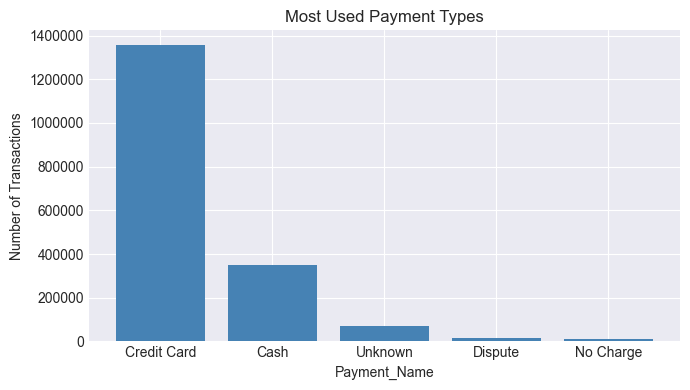

In [20]:
payments_counts = df['payment_name'].value_counts()

plt.figure(figsize=(7,4))
plt.bar(payments_counts.index,payments_counts.values,color='steelblue')
plt.title("Most Used Payment Types")
plt.xlabel("Payment_Name")
plt.ylabel("Number of Transactions")
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.show()

Insight: Credit card is the most popular payment method. Most taxi apps now prompt users to tip via card, which likely drives both higher card usage and more tipping.

Q11. Do credit card users tip more than cash users?

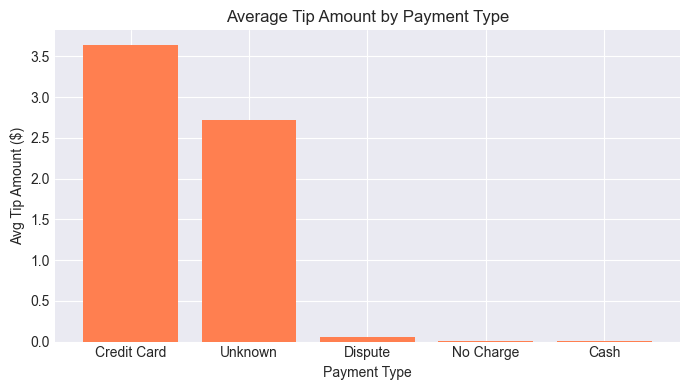

In [21]:
tip_compare = df.groupby('payment_name')['tip_amount'].mean().sort_values(ascending=False)

plt.figure(figsize=(7,4))
plt.bar(tip_compare.index,tip_compare.values,color='coral')
plt.title("Average Tip Amount by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Avg Tip Amount ($)")
plt.tight_layout()
plt.show()

Insight: Credit card users tip much more than cash users. Cash tip data is often not recorded in the system, which may affect this result.

Q12. What is average tip percentage of fare amount?

In [22]:
# only calculate on valid fares to avoid divide-by-zero

valid_fare = df[df['fare_amount'] > 0].copy()
valid_fare['tip_percentage'] = (valid_fare['tip_amount']/valid_fare['fare_amount'])*100
avg_tip_pct = valid_fare['tip_percentage'].mean()
print(f"Average Tip Percentage: {round(avg_tip_pct, 2)}%")

Average Tip Percentage: 21.41%


Insight: On average, passengers tip about 21% of their fare — which is in line with the standard tipping norm in the US.

Q13. What is the average revenue per mile? (My own question)
This shows which trips are most profitable for drivers.

In [23]:
valid_distance = df[df['trip_distance'] > 0].copy()
valid_distance['revenue_per_mile'] = valid_distance['total_amount'] / valid_distance['trip_distance']

avg_rpm = valid_distance.groupby('trip_type')['revenue_per_mile'].mean()
print("Average Revenue per mile by Trip Type")
print(avg_rpm.round(2))

Average Revenue per mile by Trip Type
trip_type
Short (0-3 mi)      16.25
Medium (3-10 mi)     6.15
Long (10+ mi)        4.51
Name: revenue_per_mile, dtype: float64


Insight: Short trips often generate more revenue per mile because of base fare and fixed charges. Long trips cover more distance but at a lower per-mile rate.

🚗 Section 4 — Trip Analysis

Q14. What is distribution of trip distance? (Short vs medium vs long trips)

trip_type
Short (0-3 mi)      1282661
Medium (3-10 mi)     376420
Long (10+ mi)        140901
Name: count, dtype: int64


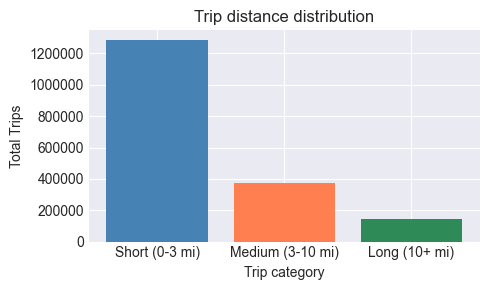

In [24]:
trip_dist = df['trip_type'].value_counts()
print(trip_dist)
plt.figure(figsize=(5,3))
plt.bar(trip_dist.index,trip_dist.values,color=['steelblue','coral','seagreen'])
plt.title("Trip distance distribution")
plt.xlabel("Trip category")
plt.ylabel("Total Trips")
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.show()

Insight: Most trips are short-distance (under 3 miles). People mainly use taxis for quick local rides in NYC, not long-distance travel.

Q15. How many passengers per trip usually?

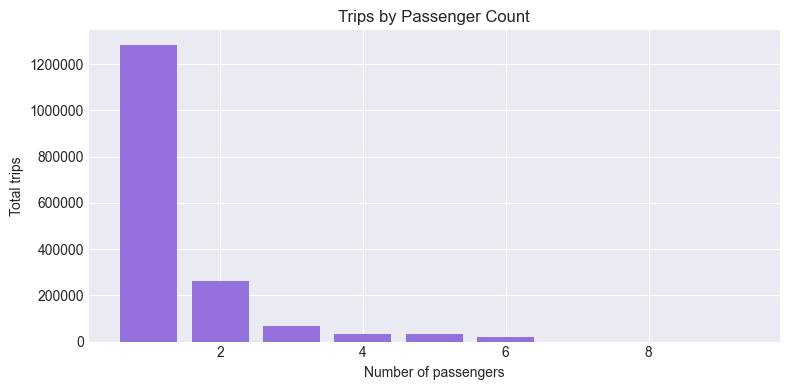

In [25]:
df = df[df['passenger_count'] > 0]
passenger_trip = df['passenger_count'].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(passenger_trip.index,passenger_trip.values,color='mediumpurple')
plt.title("Trips by Passenger Count")
plt.xlabel("Number of passengers")
plt.ylabel("Total trips")
plt.ticklabel_format(style='plain',axis='y')
plt.tight_layout()
plt.show()

Insight: Single-passenger trips dominate. This tells us taxis are mostly used for solo commuting, not group travel.

Q16. Solo vs Group travel — what percentage is each?

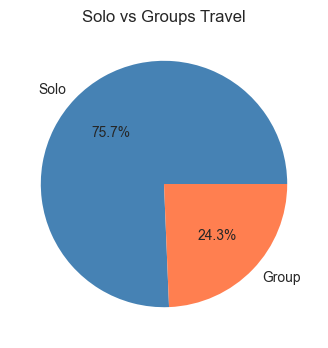

In [26]:
Travel_count = df['travel_type'].value_counts()

plt.figure(figsize=(5,4))
plt.pie(Travel_count.values,labels=Travel_count.index,autopct='%1.1f%%',colors=['steelblue','coral'])
plt.title("Solo vs Groups Travel")
plt.show()

Q17. What percentage of trips are under 1 mile?

Trips under 1 mile: 21.56%


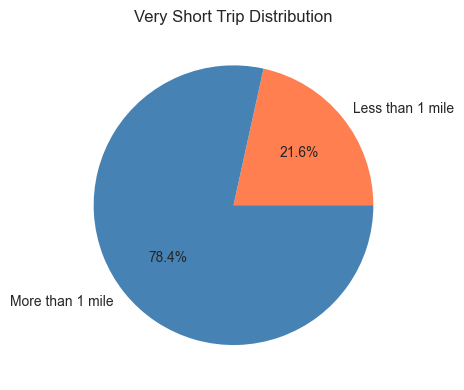

In [27]:
short_trip = df[df['trip_distance'] < 1]
short_trip_pct = (len(short_trip) / len(df))* 100
print(f"Trips under 1 mile: {round(short_trip_pct, 2)}%")

labels = ['Less than 1 mile','More than 1 mile']
counts = [len(short_trip),len(df) - len(short_trip)]

plt.figure(figsize=(5,4))
plt.pie(counts,labels=labels,autopct='%1.1f%%',colors=['coral','steelblue'])
plt.title("Very Short Trip Distribution")
plt.tight_layout()
plt.show()

Insight: About 21% of all trips are under 1 mile. These may be lazy trips or riders avoiding traffic on foot. It is worth exploring if these trips are profitable.

Q18. What is the average trip duration?

In [28]:
# keep only valid durations (positive values only)
valid_duration = df[df['trip_duration'] > 0]
avg_duration = valid_duration['trip_duration'].mean()
print(f"Average Trip Duration is: {round(avg_duration, 2)} minutes")

Average Trip Duration is: 16.87 minutes


Insight: The average trip lasts around 15-20 minutes. This is typical for NYC where distances are short but traffic can be heavy.

🔍 Section 5 — Outlier Analysis

Q19. Are there trips with 0 or negative fare? (Data quality issue)

In [29]:
invaild_fare = df[df['fare_amount'] <= 0]
print(f"Trips with Zero or negative fare: {len(invaild_fare)}")
print(f"Trips is {round(len(invaild_fare) / len(df)*100,2)}% of Total Trips")

Trips with Zero or negative fare: 13078
Trips is 0.77% of Total Trips


Q20. Are there trips with 0 passengers? (Ghost trips?)

In [30]:
invaild_passengers = df[df['passenger_count'] <= 0]
print(f"Trips with Zero Passengers: {len(invaild_passengers)}")
print(f"That is {round(len(invaild_passengers) / len(df)*100, 2)}% of Total Trips")

Trips with Zero Passengers: 0
That is 0.0% of Total Trips


Q21. Are there trips longer than 100 miles? (Outliers?)

In [31]:
long_trip = df[df['trip_distance'] > 100 ]
print(f"Trip over 100 miles: {len(long_trip)}")

Trip over 100 miles: 36


Q22. Are there trips with fare above $500? (Fraud detection)

In [32]:
high_fare = df[df['fare_amount'] > 500]

print(f"Trips with Fare Above $500: {len(high_fare)}")

Trips with Fare Above $500: 13


🏁 Final Summary — Key Findings & My Observations

What I Found:

1.Revenue grew every year from 2021 to 2023 — NYC taxi business clearly recovered after COVID.
2.Fares went up each year (2021: ~19). This suggests inflation and NYC fare hikes.
3.Evening peak (6 PM) is the busiest hour — drivers should focus on evening shifts.
4.Thursday and Friday are the busiest days. Weekends (especially Sunday) are slow.
5.Credit card users tip more — promoting card payments could benefit drivers.
6.Most trips are solo and short-distance — taxis are mainly used for individual urban commuting.
7.21% of trips are under 1 mile — these are very common but may have lower profitability.
8.Average tip is 21% — passengers are fairly generous with tipping overall.

What I Would Recommend:

Increase drivers during Thursday and Friday evenings to meet peak demand.
Encourage credit card payments — more tips for drivers means better service.
Review pricing on very short trips (<1 mile) — base fares might need adjustment.
Continue tracking 2024 data to see if the recovery trend continues.
